# Group-level distributional anomaly detection

Identify county × landcover color distributions that diverge from statewide baselines.


In [4]:
# Optional Colab Drive mount.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError:
    pass  # Continue locally.


In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
from scipy.spatial.distance import jensenshannon
import geopandas as gpd
import plotly.express as px
import urllib.request, zipfile
from matplotlib.colors import LinearSegmentedColormap


## Inputs

Load the color-count dataset from the optional Colab or local path.


In [2]:
from pathlib import Path
DF_FILENAME = "Capstone2025_nsi_lvl9_with_landcover_and_color.csv.gz"
candidates = [
    "/content/drive/MyDrive/Capstone/" + DF_FILENAME,  # Optional Colab path
]
PROJECT_ROOT = Path.cwd()
for _ in range(6):
    if (PROJECT_ROOT / "dataset").exists() or (PROJECT_ROOT / "website").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "dataset" if (PROJECT_ROOT / "dataset").exists() else PROJECT_ROOT / "website" / "backend" / "data"
candidates.extend([str(DATA_DIR / DF_FILENAME), str(DATA_DIR / DF_FILENAME.replace(".gz", ""))])
df_path = None
for p in candidates:
    if Path(p).exists():
        df_path = p
        break
if df_path is None:
    raise FileNotFoundError(f"Data file not found. Tried: {candidates}")
df = pd.read_csv(df_path)
print(f"Loaded from: {df_path}")
df.head()

Loaded from: c:\Users\sardo\OneDrive\Desktop\Classes\Wildfire-Property-Intelligence\dataset\Capstone2025_nsi_lvl9_with_landcover_and_color.csv.gz


,h3,fips,st_damcat,bldgtype,lc_type,loc,clr,clr_cc
0,8929a960d6fffff,6047,RES,M,urban+crop,POINT(-120.828147398273 37.0724076637771),orange,8
1,8929a978c07ffff,6047,RES,M,urban+crop,POINT(-120.63428156983 36.9838900827867),orange,8
2,892836da147ffff,6047,RES,M,urban+crop,POINT(-120.464731172229 37.3234892623252),orange,11
3,892836c644fffff,6047,RES,M,urban+crop,POINT(-120.787252301526 37.4298893882365),orange,12
4,892836d736fffff,6047,RES,M,urban+crop,POINT(-120.716239893409 37.3391233398179),orange,1


## Baseline construction

County × landcover color distributions are compared with statewide landcover baselines.


In [3]:
county_lc_color = df.groupby(['fips', 'lc_type', 'clr'])['clr_cc'].sum().reset_index(name='count')
county_lc_totals = df.groupby(['fips', 'lc_type'])['clr_cc'].sum().reset_index(name='total')
county_lc_color = county_lc_color.merge(county_lc_totals, on=['fips', 'lc_type'])
county_lc_color['proportion'] = county_lc_color['count'] / county_lc_color['total']

county_lc_color.head(20)

,fips,lc_type,clr,count,total,proportion
0,6001,forest,alabaster,891,10026,0.088869
1,6001,forest,amber,579,10026,0.057750
2,6001,forest,cocoa,3656,10026,0.364652
3,6001,forest,green,1843,10026,0.183822
4,6001,forest,grey,1,10026,0.000100
5,6001,forest,indigo,1,10026,0.000100
6,6001,forest,navy,1063,10026,0.106024
7,6001,forest,orange,1213,10026,0.120985
8,6001,forest,red,779,10026,0.077698
9,6001,grass,alabaster,9,34,0.264706


In [4]:
color_by_lc = df.groupby(['lc_type', 'clr'])['clr_cc'].sum().unstack(fill_value=0)
color_by_lc = color_by_lc.div(color_by_lc.sum(axis=1), axis=0)
color_by_lc


clr,alabaster,amber,aqua,aquamarine,auburn,azure,bar,beige,blue,brown,...,plum,purple,red,sage,scarlet,sienna,tan,terracotta,verde,yellow
lc_type,,,,,,,,,,,,,,,,,,,,,
barren,0.102273,0.041921,0.001982,0.008519,0.000084,0.001898,0.000084,0.009911,0.000801,0.006495,...,0.000253,0.017292,0.069293,0.002488,0.000000,0.001307,0.000000,0.004007,0.000000,0.000337
crop,0.226058,0.007698,0.002706,0.011456,0.000120,0.020086,0.014734,0.007848,0.007066,0.146165,...,0.000361,0.014884,0.015726,0.034519,0.000150,0.003608,0.001082,0.018643,0.001323,0.000000
forest,0.078258,0.010738,0.003359,0.002538,0.000002,0.006177,0.000550,0.007171,0.008072,0.202637,...,0.000051,0.005919,0.009758,0.062577,0.000004,0.000778,0.004199,0.032895,0.022647,0.000000
grass,0.240379,0.026827,0.002068,0.001128,0.000000,0.019932,0.003573,0.009151,0.002068,0.060925,...,0.000501,0.011345,0.027391,0.018052,0.000000,0.000752,0.001567,0.028018,0.002068,0.000000
other,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
shrub,0.100819,0.023163,0.005601,0.002252,0.000000,0.024789,0.001148,0.019942,0.013185,0.129642,...,0.000224,0.006704,0.040286,0.036445,0.000015,0.003363,0.004064,0.035431,0.004698,0.000157
urban,0.053622,0.051934,0.000103,0.000038,0.000817,0.015710,0.000225,0.009185,0.007013,0.022942,...,0.000331,0.040057,0.062294,0.008774,0.002501,0.003615,0.000000,0.077469,0.000000,0.000068
urban+barren,0.085809,0.108148,0.000912,0.000608,0.000028,0.000668,0.000007,0.005137,0.001456,0.003187,...,0.000163,0.061133,0.142423,0.001180,0.000049,0.000922,0.000000,0.009698,0.000000,0.000226
urban+crop,0.081917,0.045936,0.004422,0.009249,0.000309,0.028559,0.001191,0.005290,0.007566,0.145122,...,0.000926,0.037373,0.055620,0.038822,0.002050,0.016561,0.000203,0.067317,0.003305,0.006531


In [5]:
color_by_lc.head()


clr,alabaster,amber,aqua,aquamarine,auburn,azure,bar,beige,blue,brown,...,plum,purple,red,sage,scarlet,sienna,tan,terracotta,verde,yellow
lc_type,,,,,,,,,,,,,,,,,,,,,
barren,0.102273,0.041921,0.001982,0.008519,0.000084,0.001898,0.000084,0.009911,0.000801,0.006495,...,0.000253,0.017292,0.069293,0.002488,0.000000,0.001307,0.000000,0.004007,0.000000,0.000337
crop,0.226058,0.007698,0.002706,0.011456,0.000120,0.020086,0.014734,0.007848,0.007066,0.146165,...,0.000361,0.014884,0.015726,0.034519,0.000150,0.003608,0.001082,0.018643,0.001323,0.000000
forest,0.078258,0.010738,0.003359,0.002538,0.000002,0.006177,0.000550,0.007171,0.008072,0.202637,...,0.000051,0.005919,0.009758,0.062577,0.000004,0.000778,0.004199,0.032895,0.022647,0.000000
grass,0.240379,0.026827,0.002068,0.001128,0.000000,0.019932,0.003573,0.009151,0.002068,0.060925,...,0.000501,0.011345,0.027391,0.018052,0.000000,0.000752,0.001567,0.028018,0.002068,0.000000
other,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
def compute_divergence(county_fips, lc_type, county_data, baseline):
    county_colors = county_data[(county_data['fips'] == county_fips) & (county_data['lc_type'] == lc_type)]

    # Align county colors with the statewide baseline.
    county_dist = pd.Series(0.0, index=baseline.columns)
    for _, row in county_colors.iterrows():
        county_dist[row['clr']] = row['proportion']

    b_dist = baseline.loc[lc_type]

    divergence = jensenshannon(county_dist, b_dist)

    return divergence

In [7]:
compute_divergence(6073, 'forest', county_lc_color, color_by_lc)

0.581494985757395

## Divergence scoring


In [8]:
county_lc_groups = county_lc_color[['fips', 'lc_type']].drop_duplicates()

divergences = []
for _, row in county_lc_groups.iterrows():
    fips = row['fips']
    lc = row['lc_type']

    div = compute_divergence(fips, lc, county_lc_color, color_by_lc)
    divergences.append({
        'fips': fips,
        'lc_type': lc,
        'divergence': div
    })

divergence_df = pd.DataFrame(divergences)
print(f"{len(divergence_df)} divergence scores")
divergence_df.head(10)

470 divergence scores


,fips,lc_type,divergence
0,6001,forest,0.565040
1,6001,grass,0.377538
2,6001,shrub,0.431759
3,6001,urban,0.404665
4,6001,urban+barren,0.171058
5,6001,urban+crop,0.536547
6,6001,urban+forest,0.521550
7,6001,urban+grass,0.472593
8,6001,urban+other,0.429312
9,6001,urban+shrub,0.394256


In [9]:
divergence_df['divergence'].mean(), divergence_df['divergence'].min(), divergence_df['divergence'].max()

(0.5757209432836554, 0.0, 0.8111161540284432)

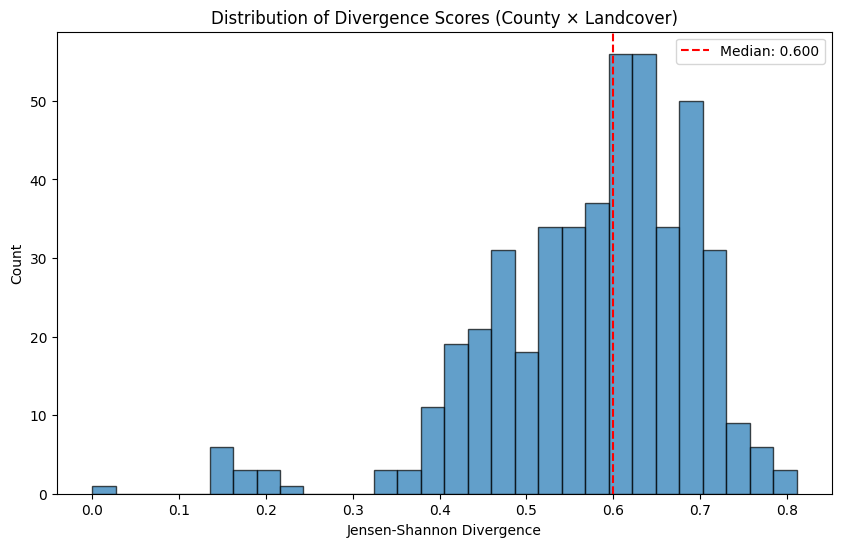

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(divergence_df['divergence'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Jensen-Shannon Divergence')
plt.ylabel('Count')
plt.title('Distribution of Divergence Scores (County × Landcover)')
plt.axvline(divergence_df['divergence'].median(), color='red', linestyle='--', label=f'Median: {divergence_df["divergence"].median():.3f}')
plt.legend()
plt.show()

In [11]:
threshold = divergence_df['divergence'].quantile(0.9)
divergence_df['anomalous'] = divergence_df['divergence'] >= threshold

print(f"Threshold for top 10%: {threshold:.3f}")
print(f"Number of anomalous groups: {divergence_df['anomalous'].sum()}")

divergence_df.nlargest(20, 'divergence')

Threshold for top 10%: 0.704
Number of anomalous groups: 47


,fips,lc_type,divergence,anomalous
53,6013,urban+other,0.811116,True
98,6027,crop,0.809519,True
223,6057,shrub,0.785089,True
173,6043,grass,0.777787,True
11,6003,shrub,0.770173,True
37,6011,grass,0.766375,True
189,6049,grass,0.766375,True
84,6023,urban+barren,0.761581,True
132,6033,urban+crop,0.760526,True
41,6011,urban+grass,0.755588,True


In [12]:
county_anomaly_counts = divergence_df[divergence_df['anomalous']].groupby('fips').size().reset_index(name='num_anomalies')

county_avg_div = divergence_df.groupby('fips')['divergence'].mean().reset_index(name='avg_divergence')

county_summary = county_anomaly_counts.merge(county_avg_div, on='fips', how='right')
county_summary['num_anomalies'] = county_summary['num_anomalies'].fillna(0)
county_summary.head(5)

,fips,num_anomalies,avg_divergence
0,6001,0.0,0.430432
1,6003,3.0,0.724331
2,6005,1.0,0.664166
3,6007,0.0,0.544815
4,6009,0.0,0.627632


## Spatial visualization


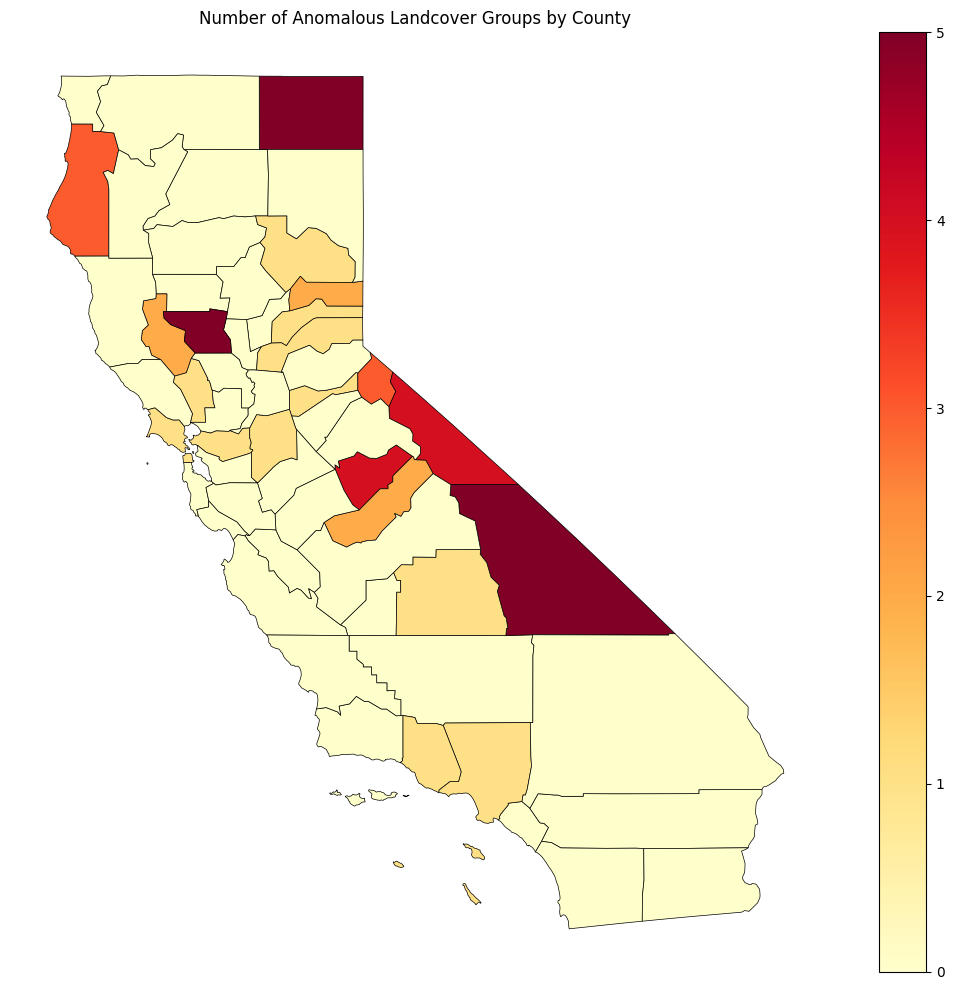

In [13]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
counties_gdf = gpd.read_file(url)

ca_counties = counties_gdf[counties_gdf['STATE'] == '06'].copy()
ca_counties['fips'] = ca_counties['id'].astype(int)

ca_counties = ca_counties.merge(county_summary, on='fips', how='left')

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ca_counties.plot(column='num_anomalies', cmap='YlOrRd', legend=True, ax=ax,
                 edgecolor='black', linewidth=0.5, missing_kwds={'color': 'lightgrey'})
plt.title('Number of Anomalous Landcover Groups by County')
plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
ca_counties_plotly = ca_counties.drop(columns=['num_anomalies', 'avg_divergence'], errors='ignore')
ca_counties_plotly = ca_counties_plotly.merge(county_summary, on='fips', how='left')

fig = px.choropleth(ca_counties_plotly,
                    geojson=ca_counties_plotly.geometry,
                    locations=ca_counties_plotly.index,
                    color='num_anomalies',
                    hover_data=['fips', 'num_anomalies', 'avg_divergence'],
                    color_continuous_scale='YlOrRd',
                    title='Anomalous Landcover Groups by County (interactive)')

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(height=700)
fig.show()

In [15]:
county_6027 = divergence_df[(divergence_df['fips'] == 6027) & (divergence_df['anomalous'])]
print(f"County 6027 anomalous groups:")
print(county_6027.sort_values('divergence', ascending=False))

for _, row in county_6027.iterrows():
    lc = row['lc_type']
    print(f"\n{'='*60}")
    print(f"LANDCOVER: {lc} (divergence: {row['divergence']:.3f})")
    print(f"{'='*60}")

    county_colors = county_lc_color[(county_lc_color['fips'] == 6027) &
                                     (county_lc_color['lc_type'] == lc)]

    baseline_dist = color_by_lc.loc[lc]

    print("\nCounty's top colors:")
    print(county_colors.nlargest(5, 'proportion')[['clr', 'proportion', 'count']])

    print("\nBaseline's top colors:")
    baseline_top = baseline_dist.nlargest(5)
    print(baseline_top)

County 6027 anomalous groups:
     fips       lc_type  divergence  anomalous
98   6027          crop    0.809519       True
97   6027        barren    0.723923       True
103  6027    urban+crop    0.714181       True
101  6027         shrub    0.706605       True
102  6027  urban+barren    0.706027       True

LANDCOVER: barren (divergence: 0.724)

County's top colors:
        clr  proportion  count
900   beige    0.427350    150
901  coffee    0.133903     47
908  orange    0.133903     47
899    aqua    0.111111     39
904   ivory    0.071225     25

Baseline's top colors:
clr
cocoa        0.413690
orange       0.122264
alabaster    0.102273
navy         0.101978
red          0.069293
Name: barren, dtype: float64

LANDCOVER: crop (divergence: 0.810)

County's top colors:
       clr  proportion  count
911  beige         0.5      1
912  ivory         0.5      1

Baseline's top colors:
clr
alabaster    0.226058
brown        0.146165
cocoa        0.135641
coffee       0.062393
gray     

## Color-similarity follow-up


In [16]:
clr_bldgtype_distributions = df.groupby(['clr', 'bldgtype'])['clr_cc'].sum().unstack(fill_value=0)
clr_bldgtype_distributions = clr_bldgtype_distributions.div(clr_bldgtype_distributions.sum(axis=1), axis=0)
clr_bldgtype_distributions.columns = ['bldgtype_' + c for c in clr_bldgtype_distributions.columns]
clr_bldgtype_distributions = clr_bldgtype_distributions.reset_index()

clr_damcat_distributions = df.groupby(['clr', 'st_damcat'])['clr_cc'].sum().unstack(fill_value=0)
clr_damcat_distributions = clr_damcat_distributions.div(clr_damcat_distributions.sum(axis=1), axis=0)
clr_damcat_distributions.columns = ['damcat_' + c for c in clr_damcat_distributions.columns]
clr_damcat_distributions = clr_damcat_distributions.reset_index()

clr_lc_distributions = df.groupby(['clr', 'lc_type'])['clr_cc'].sum().unstack(fill_value=0)
clr_lc_distributions = clr_lc_distributions.div(clr_lc_distributions.sum(axis=1), axis=0)
clr_lc_distributions.columns = ['lc_' + c for c in clr_lc_distributions.columns]
clr_lc_distributions = clr_lc_distributions.reset_index()

distributions = clr_bldgtype_distributions.merge(clr_damcat_distributions, on='clr').merge(clr_lc_distributions, on='clr')
distributions = distributions.set_index('clr')

distributions.head()

,bldgtype_C,bldgtype_H,bldgtype_M,bldgtype_S,bldgtype_W,damcat_COM,damcat_IND,damcat_PUB,damcat_RES,lc_barren,...,lc_grass,lc_other,lc_shrub,lc_urban,lc_urban+barren,lc_urban+crop,lc_urban+forest,lc_urban+grass,lc_urban+other,lc_urban+shrub
clr,,,,,,,,,,,,,,,,,,,,,
alabaster,0.001872,0.037555,0.441270,0.002377,0.516926,0.000000,0.000000,0.000000,1.000000,0.003884,...,0.006142,0.0,0.021651,0.487036,0.038896,0.073783,0.108839,0.157632,0.000043,0.029163
amber,0.011349,0.034038,0.439957,0.004668,0.509989,0.017830,0.002462,0.001093,0.978615,0.002028,...,0.000873,0.0,0.006336,0.600874,0.062445,0.052704,0.078198,0.147409,0.000063,0.037905
aqua,0.000556,0.061289,0.426796,0.002318,0.509040,0.000000,0.000000,0.000000,1.000000,0.004358,...,0.003060,0.0,0.069634,0.054242,0.023922,0.230598,0.133055,0.291701,0.000371,0.029393
aquamarine,0.000566,0.048698,0.447339,0.002718,0.500680,0.000000,0.000000,0.000000,1.000000,0.022877,...,0.002039,0.0,0.034202,0.024236,0.019479,0.589128,0.036353,0.078143,0.000000,0.010759
auburn,0.455656,0.004404,0.248248,0.103504,0.188188,0.867467,0.119920,0.012613,0.000000,0.000400,...,0.000000,0.0,0.000000,0.927327,0.001602,0.034835,0.015616,0.011211,0.000000,0.008008


In [17]:
color_pairs_county_split = []

for i, color1 in enumerate(distributions.index):
    for color2 in distributions.index[i+1:]:
        js_dist = jensenshannon(distributions.loc[color1], distributions.loc[color2])

        if js_dist < 0.15:  # similar context
            counties1 = set(df[df['clr'] == color1]['fips'].unique())
            counties2 = set(df[df['clr'] == color2]['fips'].unique())

            overlap = len(counties1 & counties2) / len(counties1 | counties2)

            if overlap < 0.3:  # low county overlap
                color_pairs_county_split.append({
                    'color1': color1,
                    'color2': color2,
                    'context_similarity': 1 - js_dist,
                    'county_overlap': overlap,
                    'counties1_only': len(counties1 - counties2),
                    'counties2_only': len(counties2 - counties1)
                })

result_df = pd.DataFrame(color_pairs_county_split).sort_values('context_similarity', ascending=False)
result_df

,color1,color2,context_similarity,county_overlap,counties1_only,counties2_only
75,purple,red,0.963392,0.250000,8,16
36,brown,sage,0.961585,0.235294,8,18
73,orange,red,0.957688,0.200000,16,16
12,amber,purple,0.950096,0.200000,24,8
41,cocoa,orange,0.946087,0.235294,10,16
...,...,...,...,...,...,...
38,cocoa,green,0.855189,0.296296,10,9
57,ivory,red,0.854948,0.000000,18,24
66,lilac,olive,0.853620,0.200000,16,24
50,green,sage,0.853520,0.000000,17,26


In [18]:
top_pairs = result_df.head(10)

for _, row in top_pairs.iterrows():
    c1, c2 = row['color1'], row['color2']

    print(f"\n{'='*70}")
    print(f"{c1.upper()} vs {c2.upper()}")
    print(f"Context similarity: {row['context_similarity']:.3f} (very similar usage)")
    print(f"County overlap: {row['county_overlap']:.3f} (low = different counties)")
    print(f"{'='*70}")

    counties1 = df[df['clr'] == c1]['fips'].unique()
    counties2 = df[df['clr'] == c2]['fips'].unique()

    print(f"\nCounties using {c1}: {sorted(counties1)[:10]}...")
    print(f"Counties using {c2}: {sorted(counties2)[:10]}...")

    print(f"\n{c1} landcover distribution:")
    lc_cols = [c for c in distributions.columns if c.startswith('lc_')]
    print(distributions.loc[c1, lc_cols].nlargest(3))

    print(f"\n{c2} landcover distribution:")
    print(distributions.loc[c2, lc_cols].nlargest(3))


PURPLE vs RED
Context similarity: 0.963 (very similar usage)
County overlap: 0.250 (low = different counties)

Counties using purple: [6001, 6009, 6019, 6025, 6029, 6031, 6055, 6059, 6065, 6067]...
Counties using red: [6001, 6005, 6013, 6015, 6019, 6021, 6029, 6035, 6059, 6061]...

purple landcover distribution:
lc_urban          0.683019
lc_urban+grass    0.106300
lc_urban+crop     0.063193
Name: purple, dtype: float64

red landcover distribution:
lc_urban           0.634876
lc_urban+grass     0.125709
lc_urban+barren    0.072439
Name: red, dtype: float64

BROWN vs SAGE
Context similarity: 0.962 (very similar usage)
County overlap: 0.235 (low = different counties)

Counties using brown: [6007, 6013, 6017, 6053, 6061, 6077, 6079, 6081, 6083, 6087]...
Counties using sage: [6003, 6011, 6013, 6023, 6027, 6033, 6037, 6039, 6041, 6043]...

brown landcover distribution:
lc_urban+forest    0.298832
lc_urban+grass     0.218578
lc_urban           0.182679
Name: brown, dtype: float64

sage land

In [19]:
c1, c2 = 'ivory', 'alabaster'

js_dist = jensenshannon(distributions.loc[c1], distributions.loc[c2])

counties1 = set(df[df['clr'] == c1]['fips'].unique())
counties2 = set(df[df['clr'] == c2]['fips'].unique())
overlap = len(counties1 & counties2) / len(counties1 | counties2)

print(f"IVORY vs ALABASTER")
print(f"Context similarity: {1 - js_dist:.3f}")
print(f"County overlap: {overlap:.3f}")
print(f"\nCounties using ivory only: {len(counties1 - counties2)}")
print(f"Counties using alabaster only: {len(counties2 - counties1)}")
print(f"Counties using both: {len(counties1 & counties2)}")

print(f"\nIvory landcover distribution:")
lc_cols = [c for c in distributions.columns if c.startswith('lc_')]
print(distributions.loc['ivory', lc_cols].nlargest(3))

print(f"\nAlabaster landcover distribution:")
print(distributions.loc['alabaster', lc_cols].nlargest(3))

IVORY vs ALABASTER
Context similarity: 0.815
County overlap: 0.000

Counties using ivory only: 18
Counties using alabaster only: 32
Counties using both: 0

Ivory landcover distribution:
lc_urban           0.861779
lc_urban+grass     0.040876
lc_urban+forest    0.037145
Name: ivory, dtype: float64

Alabaster landcover distribution:
lc_urban           0.487036
lc_urban+grass     0.157632
lc_urban+forest    0.108839
Name: alabaster, dtype: float64


## Exports


In [23]:
divergence_df.to_csv('jsd_conditional_divergence.csv', index=False)

county_summary.to_csv('jsd_conditional_county_summary.csv', index=False)

result_df.to_csv('color_pairs_analysis.csv', index=False)

## Optional follow-up

The disconnected shapefile download remains available for a separate county-level map.


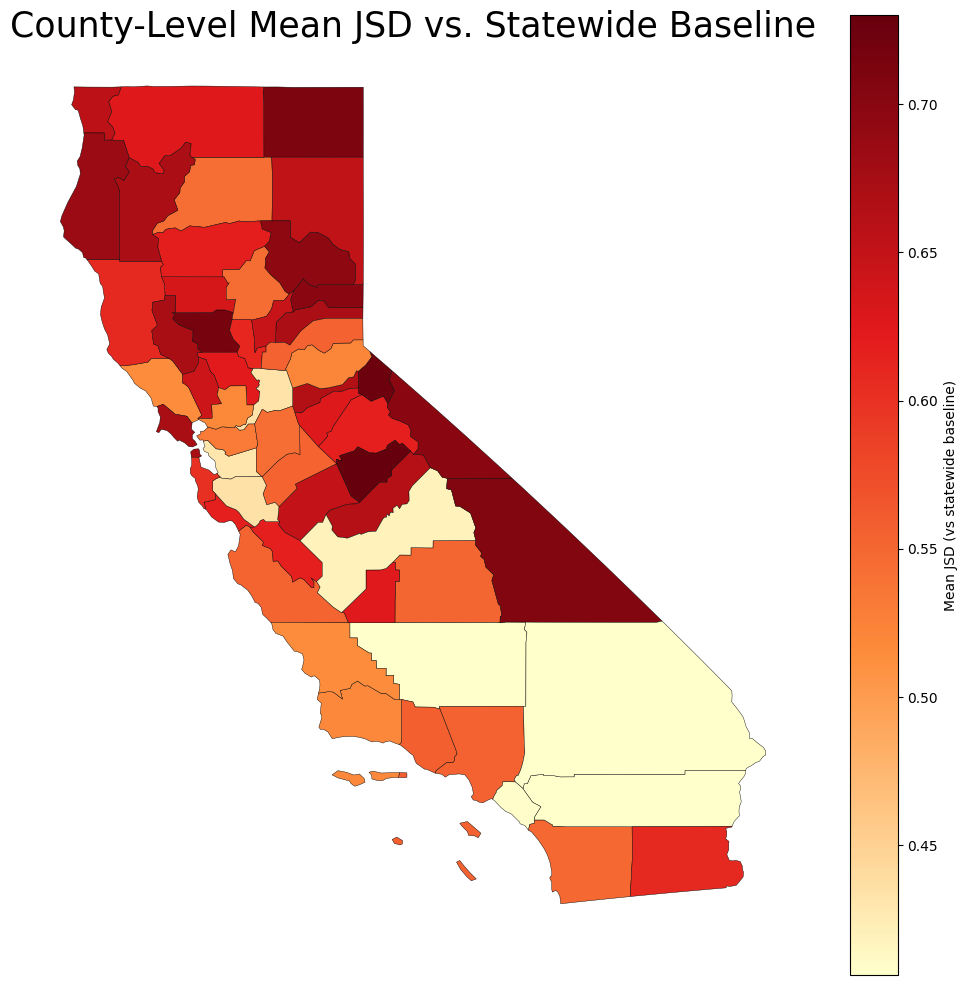

In [ ]:
url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
urllib.request.urlretrieve(url, "counties.zip")
with zipfile.ZipFile("counties.zip", "r") as z:
    z.extractall("counties")

df = pd.read_csv('jsd_conditional_divergence.csv')
county_jsd = df.groupby('fips')['divergence'].mean().reset_index()
county_jsd.columns = ['fips', 'mean_jsd']
county_jsd['fips'] = county_jsd['fips'].astype(str).str.zfill(5)

gdf = gpd.read_file("counties/cb_2021_us_county_20m.shp")
gdf = gdf[gdf['STATEFP'] == '06'].copy()
gdf['fips'] = gdf['GEOID']

gdf = gdf.merge(county_jsd, on='fips', how='left')

cmap = LinearSegmentedColormap.from_list('jsd', ['#ffffcc', '#fd8d3c', '#e31a1c', '#67000d'])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(
    column='mean_jsd',
    ax=ax,
    cmap=cmap,
    edgecolor='black',
    linewidth=0.3,
    legend=True,
    legend_kwds={'label': 'Mean JSD (vs statewide baseline)'}
)
ax.set_title('County-Level Mean JSD vs. Statewide Baseline', fontsize=17)
ax.axis('off')
plt.tight_layout()
plt.savefig('county_jsd_baseline_map.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()